# Aggregration & Grouping

### .groupby() Function

In [2]:
import pandas as pd
df = pd.DataFrame({
    "Department": ["HR", "HR", "IT", "IT", "Marketing", "Marketing", "Sales", "Sales"],
    "Team": ["A", "A", "B", "B", "C", "C", "D", "D"],
    "Gender": ["M", "F", "M", "F", "M", "F", "M", "F"],
    "Salary": [85, 90, 78, 85, 92, 88, 75, 80],
    "Age": [23, 25, 30, 22, 28, 26, 21, 27],
    "JoinDate": pd.to_datetime([
        "2020-01-10", "2020-02-15", "2021-03-20", "2021-04-10",
        "2020-05-30", "2020-06-25", "2021-07-15", "2021-08-01"
    ])
})  


In [3]:
df

,Department,Team,Gender,Salary,Age,JoinDate
0,HR,A,M,85,23,2020-01-10
1,HR,A,F,90,25,2020-02-15
2,IT,B,M,78,30,2021-03-20
3,IT,B,F,85,22,2021-04-10
4,Marketing,C,M,92,28,2020-05-30
5,Marketing,C,F,88,26,2020-06-25
6,Sales,D,M,75,21,2021-07-15
7,Sales,D,F,80,27,2021-08-01


In [4]:
df.groupby("Department")["Salary"].mean()

Department
HR           87.5
IT           81.5
Marketing    90.0
Sales        77.5
Name: Salary, dtype: float64

In [5]:
df.groupby("Team")["Salary"].sum()  

Team
A    175
B    163
C    180
D    155
Name: Salary, dtype: int64

In [6]:
df.groupby("Team")["Salary"].count()

Team
A    2
B    2
C    2
D    2
Name: Salary, dtype: int64

In [7]:
df.groupby("Team")["Salary"].min()  

Team
A    85
B    78
C    88
D    75
Name: Salary, dtype: int64

In [8]:
df.groupby("Team")["Salary"].max()  

Team
A    90
B    85
C    92
D    80
Name: Salary, dtype: int64

In [9]:
df.groupby(["Team", "Gender"])["Salary"].mean()

Team  Gender
A     F         90.0
      M         85.0
B     F         85.0
      M         78.0
C     F         88.0
      M         92.0
D     F         80.0
      M         75.0
Name: Salary, dtype: float64

### Custom Aggregations with .agg()

In [10]:
df.groupby("Team")["Salary"].agg(["mean", "max", "min"])

,mean,max,min
Team,,,
A,87.5,90,85
B,81.5,85,78
C,90.0,92,88
D,77.5,80,75


In [14]:
df.groupby("Team")["Salary"].agg(
    avg_score="mean",
    high_score="max"
)                             # name the functions

,avg_score,high_score
Team,,
A,87.5,90
B,81.5,85
C,90.0,92
D,77.5,80


In [13]:
df.groupby("Team").agg({
    "Salary": "mean",
    "Age": "max"
})                                 # Apply different functions to different columns

,Salary,Age
Team,,
A,87.5,25
B,81.5,30
C,90.0,28
D,77.5,27


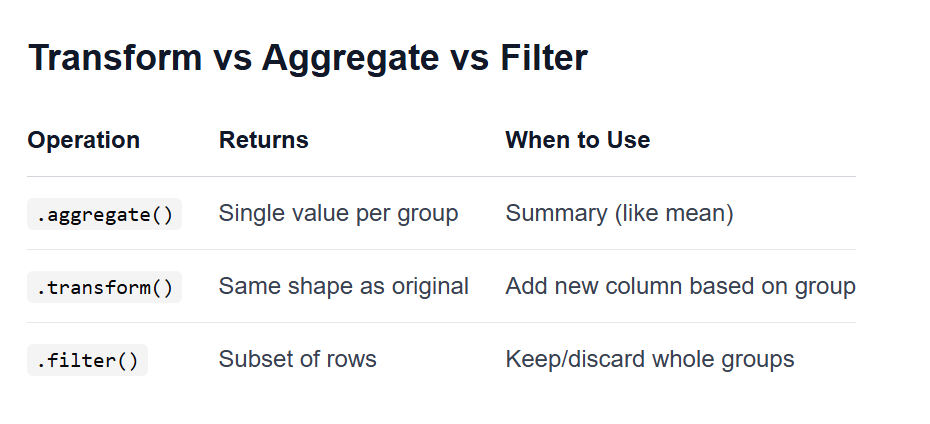

### .transform() Example:

In [16]:
df["Team Avg"] = df.groupby("Team")["Salary"].transform("mean")

In [17]:
print(df["Team Avg"])

0    87.5
1    87.5
2    81.5
3    81.5
4    90.0
5    90.0
6    77.5
7    77.5
Name: Team Avg, dtype: float64


### .filter() Example:

In [18]:
df.groupby("Team").filter(lambda x: x["Salary"].mean() > 80)

,Department,Team,Gender,Salary,Age,JoinDate,Team Avg
0,HR,A,M,85,23,2020-01-10,87.5
1,HR,A,F,90,25,2020-02-15,87.5
2,IT,B,M,78,30,2021-03-20,81.5
3,IT,B,F,85,22,2021-04-10,81.5
4,Marketing,C,M,92,28,2020-05-30,90.0
5,Marketing,C,F,88,26,2020-06-25,90.0
